In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy.stats as stats
import math
import statsmodels.api as sm
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['svg.fonttype'] = 'none'
from matplotlib import cm
import matplotlib.colors as colors
from matplotlib.patches import Rectangle
from matplotlib.patches import Polygon
import matplotlib.gridspec as gridspec

## Importing the data

In [6]:
fit_exp_5FC = pd.read_csv("Supp_data/fit_promoters_5FC.csv")
fit_exp_comp = pd.read_csv("Supp_data/growth_exp_val_mutants.csv")  # 'Relative_median_exp' is from cytometry measurements
curves_ci_5FC = pd.read_csv("Supp_data/fit_functs_5FC.csv")
s_curve = pd.read_csv("Supp_data/s_curve_5FC.csv")
comp_dme = pd.read_csv("Supp_data/DFE_comp.csv")

In [7]:
# Preparing the data for the validation mutants
#fit_exp_comp = fit_exp_comp[fit_exp_comp['Mutant_id'] != 'F3'].copy().reset_index(drop=True)
# F3 is removed because it had a growth defect in 5-FC while also growing better in SC

# Adding a new column identifying 'Promoter' 'CDS' mutations
fit_exp_comp['Location'] = fit_exp_comp['In_F3F4'].apply(lambda x: 'Promoter' if x else 'CDS')

# Computing error bars separately for the 'Promoter' and 'CDS' categories
comp_prom = fit_exp_comp[fit_exp_comp['Location'] == 'Promoter'].copy().reset_index(drop=True) 
comp_CDS = fit_exp_comp[fit_exp_comp['Location'] == 'CDS'].copy().reset_index(drop=True) 

# Error bars for prom mutations
exp_proms = np.array([comp_prom['Relative_median_exp'] - comp_prom['Min_rel_exp'],
                      comp_prom['Max_rel_exp'] - comp_prom['Relative_median_exp']])
growth_proms = np.array([comp_prom['exp_rate'] - comp_prom['Min_exp_rate'],
                         comp_prom['Max_exp_rate'] - comp_prom['exp_rate']])
s_proms = np.array([comp_prom['s_log'] - comp_prom['Min_s_log'],
                    comp_prom['Max_s_log'] - comp_prom['s_log']])

# Error bars for CDS mutations
exp_CDS = np.array([comp_CDS['Relative_median_exp'] - comp_CDS['Min_rel_exp'],
                    comp_CDS['Max_rel_exp'] - comp_CDS['Relative_median_exp']])
growth_CDS = np.array([comp_CDS['exp_rate'] - comp_CDS['Min_exp_rate'],
                       comp_CDS['Max_exp_rate'] - comp_CDS['exp_rate']])
s_CDS = np.array([comp_CDS['s_log'] - comp_CDS['Min_s_log'],
                  comp_CDS['Max_s_log'] - comp_CDS['s_log']])

## Generating the figure

In [9]:
dark2_palette = {'Wild-type': cm.Dark2.colors[1], 'pADH1': cm.Dark2.colors[2], 'pCUP1': cm.Dark2.colors[3],
               'pCYC1': cm.Dark2.colors[4], 'pGAL-L': cm.Dark2.colors[5], 'pTDH3': cm.Dark2.colors[6],
               'pTEF1': cm.Dark2.colors[7]}

mutants_palette = sns.color_palette('crest_r', 2)

plt.rcParams["axes.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 11

In [10]:
# Preparing the annotation data for the WT growth rate over validation mutants

# Selecting data at 12 uM
IC50 = fit_exp_5FC[fit_exp_5FC['[5-FC] (uM)'] == 12].copy().sort_values(by='Median_Median_rel_exp').reset_index(drop=True)

# Taking WT (AKD1123) growth rates
data_WT = IC50[IC50['Label'] == 'Wild-type'].copy().reset_index(drop=True)
med_WT = data_WT.at[0, 'Median_exp_rate']
min_WT = data_WT.at[0, 'Min_exp_rate']
max_WT = data_WT.at[0, 'Max_exp_rate']

# Preparing arrays to plot
x_valid_vals = comp_prom['Relative_median_exp']
med_data = np.full(x_valid_vals.shape[0], med_WT)
min_data = np.full(x_valid_vals.shape[0], min_WT)
max_data = np.full(x_valid_vals.shape[0], max_WT)

C:\Users\tiger\AppData\Local\Temp\ipykernel_9140\2103294808.py:55: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax3.scatter(comp_prom['Relative_median_exp'], comp_prom['s_log'], c=mutants_palette[1], zorder=3, edgecolor='black', s=20, linewidths=0.55)


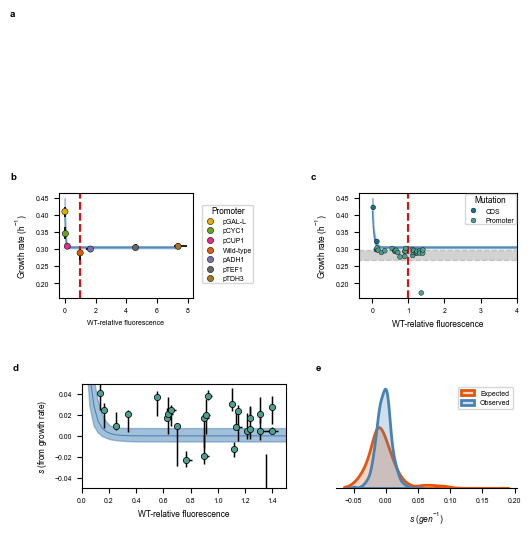

In [111]:
fig = plt.figure(constrained_layout=False, figsize=(5.91, 6.3))

gs = fig.add_gridspec(18, 20)

ax0 = fig.add_subplot(gs[0:4, 0:20])
ax1 = fig.add_subplot(gs[6:10, 0:6])
ax2 = fig.add_subplot(gs[6:10, 13:20], sharey=ax1)
ax3 = fig.add_subplot(gs[13:17, 1:10])
ax4 = fig.add_subplot(gs[13:17, 12:20])
#ax5 = fig.add_subplot(gs[16:17, 13:20], sharex=ax4)

# Removing ticks for A, where a schematics will be added manually
ax0.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
ax0.spines[:].set_visible(False)

# Fitness function at 12 uM
#IC50 = IC50[IC50['Label'] != 'Wild-type'].copy().reset_index(drop=True)
x_IC50 = np.array([IC50['Median_Median_rel_exp'] - IC50['Min_Median_rel_exp'], IC50['Max_Median_rel_exp'] - IC50['Median_Median_rel_exp']])
y_IC50 = np.array([IC50['Median_exp_rate'] - IC50['Min_exp_rate'], IC50['Max_exp_rate'] - IC50['Median_exp_rate']])

sns.scatterplot(data=IC50, x='Median_Median_rel_exp', y='Median_exp_rate', hue='Label', ax=ax1, palette=dark2_palette, zorder=3, edgecolor='black', s=20)
ax1.errorbar(IC50['Median_Median_rel_exp'], IC50['Median_exp_rate'], xerr=x_IC50, yerr=y_IC50, fmt='none', zorder=2, ecolor='black', elinewidth=1.25)
ax1.plot(curves_ci_5FC['Median_rel_exp'], curves_ci_5FC['Median_decay_5FC_12'], c="steelblue", zorder=1, linewidth=0.75,)
ax1.fill_between(curves_ci_5FC['Median_rel_exp'], curves_ci_5FC['decay_5FC_12_2_5'],
                 curves_ci_5FC['decay_5FC_12_97_5'], alpha=0.5, color="steelblue", zorder=0)
ax1.axvline(x=1, linestyle='--', color='red', zorder=1)
h_1, l_1 = ax1.get_legend_handles_labels()
ax1.legend(h_1, l_1, loc='upper left', title='Promoter', title_fontsize=6,
           bbox_to_anchor=(1.06, 0.90), fontsize=5, borderaxespad=0.15, borderpad=0.15)
ax1.set_ylabel(r"Growth rate (h$^{-1}$)", fontsize=6)
ax1.set_xlabel("WT-relative fluorescence", fontsize=5)
ax1.tick_params(axis='both', labelsize=5)

# Redoing the fitness function with the addition of validation mutants
ax2.plot(curves_ci_5FC['Median_rel_exp'], curves_ci_5FC['Median_decay_5FC_12'], c="steelblue", zorder=1, linewidth=0.75)
ax2.fill_between(curves_ci_5FC['Median_rel_exp'], curves_ci_5FC['decay_5FC_12_2_5'],
                 curves_ci_5FC['decay_5FC_12_97_5'], alpha=0.5, color="steelblue", zorder=0)
ax2.axvline(x=1, linestyle='--', color='red', zorder=1)
ax2.set_xlim(right=4)
#ax2.plot(x_valid_vals, med_data, c='grey', zorder=1, linestyle='--')
x_fill = np.linspace(ax2.get_xlim()[0], ax2.get_xlim()[1], x_valid_vals.shape[0])
ax2.fill_between(x_fill, min_data, max_data, color='grey', zorder=0, alpha=0.35, linestyle='--')

sns.scatterplot(data=fit_exp_comp, x='Relative_median_exp', y='exp_rate', hue='Location', palette=mutants_palette, edgecolor='black', ax=ax2, zorder=3, s=12)
#ax2.errorbar(comp_CDS['Relative_median_exp'], comp_CDS['Max_log_rate'], xerr=exp_CDS, yerr=growth_CDS, fmt='none', zorder=2, ecolor='black', linewidth=2)
#ax2.errorbar(comp_prom['Relative_median_exp'], comp_prom['Max_log_rate'], xerr=exp_proms, yerr=growth_proms, fmt='none', zorder=2, ecolor='black', linewidth=2)
h_2, l_2 = ax2.get_legend_handles_labels()
ax2.legend(h_2, l_2, loc='upper right', title='Mutation', title_fontsize=6,
           fontsize=5, borderaxespad=0.15, borderpad=0.15)
ax2.set_ylabel(r"Growth rate (h$^{-1}$)", fontsize=6)
ax2.set_xlabel("WT-relative fluorescence", fontsize=6)
ax2.tick_params(axis='both', labelsize=5)

# Zooming on F3-F4 validation mutants on the fitness function
ax3.scatter(comp_prom['Relative_median_exp'], comp_prom['s_log'], c=mutants_palette[1], zorder=3, edgecolor='black', s=20, linewidths=0.55)
ax3.errorbar(comp_prom['Relative_median_exp'], comp_prom['s_log'], xerr=exp_proms, yerr=s_proms,
             fmt='none', ecolor='black', zorder=2, elinewidth=1.075)
ax3.plot(s_curve['Median_rel_exp'], s_curve['Median_decay_5FC_12'], c="steelblue", zorder=1, linewidth=0.75)
ax3.fill_between(s_curve['Median_rel_exp'], s_curve['decay_5FC_12_2_5'],
                 s_curve['decay_5FC_12_97_5'], alpha=0.5, color="steelblue", zorder=0)
ax3.set_xlabel("WT-relative fluorescence", fontsize=6)
ax3.set_ylabel(r"$s$ (from growth rate)", fontsize=6)
ax3.tick_params(axis='both', labelsize=5)
ax3.set_xlim(left=0, right=1.5)
ax3.set_ylim(top=0.05, bottom=-0.05)

# Last panel: Comparing the observed and expected distributions of fitness effects
sns.kdeplot(data=comp_dme, x='s_pred', label='Expected', ax=ax4, color=cm.tab20c.colors[4], cut=0, fill=True, linewidths=2.0)
sns.kdeplot(data=comp_dme, x='Median_s_ignored', color='steelblue', label='Observed', ax=ax4, cut=0, fill=True, linewidths=2.0)
#ax4.axvline(x=np.quantile(comp_dme['Median_s_ignored'], 0.975), linestyle='--', c='steelblue')
#ax4.axvline(x=np.quantile(comp_dme['Median_s_ignored'], 0.025), linestyle='--', c='steelblue')

h_4, l_4 = ax4.get_legend_handles_labels()
ax4.legend(h_4, l_4, loc='upper right', title='',
           fontsize=5)
ax4.spines[['left', 'right', 'top']].set_visible(False)
ax4.tick_params(left=False, labelleft=False, labelsize=5)
ax4.set_ylabel('')
ax4.set_xlabel(r"$s$ ($gen^{-1}$)", fontsize=6)

ax0.annotate('a', (-35, 85), xycoords='axes points', annotation_clip=False, fontsize=7, fontweight='bold')
ax1.annotate('b', (-35, 85), xycoords='axes points', annotation_clip=False, fontsize=7, fontweight='bold')
ax2.annotate('c', (-35, 85), xycoords='axes points', annotation_clip=False, fontsize=7, fontweight='bold')
ax3.annotate('d', (-50, 85), xycoords='axes points', annotation_clip=False, fontsize=7, fontweight='bold')
ax4.annotate('e', (-14.5, 85), xycoords='axes points', annotation_clip=False, fontsize=7, fontweight='bold')

fig6 = plt.gcf()
fig6.savefig(f"Final_figs/Fig6_v2_plt.svg", bbox_inches='tight')

In [12]:
np.min(comp_prom['s_log'])

-0.2772739100409909

It is clear that the new calculation of growth rates (and thus selection coefficients) does not invalidate our previous conclusions